**Building Detection from Satellite Imagery**


In [1]:
!pip install ultralytics
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.3 MB/s eta 0:00:00
True
Tesla T4


In [2]:
from google.colab import files
files.upload()  # select your kaggle.json file

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vaibhaviisinghh","key":"455fbe1362b846771ad1c7a9abcd2ccd"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d pallav23/icg-spacenet-sandox-yolo
!unzip icg-spacenet-sandox-yolo.zip -d spacenet

Dataset URL: https://www.kaggle.com/datasets/pallav23/icg-spacenet-sandox-yolo
License(s): CC-BY-SA-4.0
100% 950M/950M [00:09<00:00, 109MB/s]

Archive:  icg-spacenet-sandox-yolo.zip
  inflating: spacenet/spacenet_buildings_yolo/README.md  
  inflating: spacenet/spacenet_buildings_yolo/dataset.yaml.template  
  inflating: spacenet/spacenet_buildings_yolo/images/AOI_3_Paris_img10.png  
  inflating: spacenet/spacenet_buildings_yolo/images/AOI_3_Paris_img100.png  
  inflating: spacenet/spacenet_buildings_yolo/images/AOI_3_Paris_img1000.png  
  inflating: spacenet/spacenet_buildings_yolo/images/AOI_3_Paris_img1001.png  
  inflating: spacenet/spacenet_buildings_yolo/images/AOI_3_Paris_img1003.png  
  inflating: spacenet/spacenet_buildings_yolo/images/AOI_3_Paris_img1007.png  
  inflating: spacenet/spacenet_buildings_yolo/images/AOI_3_Paris_img1008.png  
  inflating: spacenet/spacenet_buildings_yolo/images/AOI_3_Paris_img1009.png  
  inflating: spacenet/spacenet_buildings_yolo/images/AOI_3_Pa

In [4]:
import os
for root, dirs, files_ in os.walk('spacenet'):
    level = root.replace('spacenet', '').count(os.sep)
    if level < 3:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')

spacenet/
  spacenet_buildings_yolo/
    images/
    labels/


In [5]:
import os, glob

# Check subfolders inside images and labels
for folder in ['spacenet/spacenet_buildings_yolo/images',
               'spacenet/spacenet_buildings_yolo/labels']:
    print(f"\n{folder}:")
    for item in os.listdir(folder):
        path = os.path.join(folder, item)
        if os.path.isdir(path):
            count = len(glob.glob(f'{path}/*'))
            print(f"  {item}/ — {count} files")
        else:
            print(f"  {item}")


spacenet/spacenet_buildings_yolo/images:
  AOI_3_Paris_img1197.png
  AOI_3_Paris_img1449.png
  AOI_3_Paris_img773.png
  AOI_3_Paris_img493.png
  AOI_3_Paris_img1499.png
  AOI_3_Paris_img1772.png
  AOI_3_Paris_img716.png
  AOI_3_Paris_img59.png
  AOI_3_Paris_img373.png
  AOI_3_Paris_img402.png
  AOI_3_Paris_img897.png
  AOI_3_Paris_img1003.png
  AOI_3_Paris_img339.png
  AOI_3_Paris_img52.png
  AOI_3_Paris_img502.png
  AOI_3_Paris_img1416.png
  AOI_3_Paris_img540.png
  AOI_3_Paris_img235.png
  AOI_3_Paris_img1050.png
  AOI_3_Paris_img1125.png
  AOI_3_Paris_img147.png
  AOI_3_Paris_img1322.png
  AOI_3_Paris_img1907.png
  AOI_3_Paris_img214.png
  AOI_3_Paris_img706.png
  AOI_3_Paris_img1533.png
  AOI_3_Paris_img1275.png
  AOI_3_Paris_img895.png
  AOI_3_Paris_img1281.png
  AOI_3_Paris_img1060.png
  AOI_3_Paris_img1660.png
  AOI_3_Paris_img650.png
  AOI_3_Paris_img616.png
  AOI_3_Paris_img369.png
  AOI_3_Paris_img1908.png
  AOI_3_Paris_img1235.png
  AOI_3_Paris_img1718.png
  AOI_3_Paris_img

In [6]:
import os, shutil, glob, random, yaml
from sklearn.model_selection import train_test_split

random.seed(42)

# Get all images
all_images = sorted(glob.glob('spacenet/spacenet_buildings_yolo/images/*.png'))
all_fnames = [os.path.basename(f).replace('.png', '') for f in all_images]

print(f"Total images: {len(all_fnames)}")

# 80/10/10 split
train_f, temp_f = train_test_split(all_fnames, test_size=0.2, random_state=42)
val_f, test_f   = train_test_split(temp_f,     test_size=0.5, random_state=42)

print(f"Train: {len(train_f)}, Val: {len(val_f)}, Test: {len(test_f)}")

# Create folder structure
for split in ['train', 'val', 'test']:
    os.makedirs(f'data/{split}/images', exist_ok=True)
    os.makedirs(f'data/{split}/labels', exist_ok=True)

# Copy files
def copy_files(fnames, split):
    for fname in fnames:
        src_img = f'spacenet/spacenet_buildings_yolo/images/{fname}.png'
        src_lbl = f'spacenet/spacenet_buildings_yolo/labels/{fname}.txt'

        shutil.copy(src_img, f'data/{split}/images/{fname}.png')

        if os.path.exists(src_lbl):
            shutil.copy(src_lbl, f'data/{split}/labels/{fname}.txt')
        else:
            open(f'data/{split}/labels/{fname}.txt', 'w').close()

copy_files(train_f, 'train')
copy_files(val_f,   'val')
copy_files(test_f,  'test')

print("Files copied!")

# Verify
for split in ['train', 'val', 'test']:
    n = len(glob.glob(f'data/{split}/images/*'))
    print(f"{split}: {n} images")

# Create dataset.yaml
dataset_yaml = {
    'path': '/content/data',
    'train': 'train/images',
    'val':   'val/images',
    'test':  'test/images',
    'nc': 1,
    'names': ['building']
}

with open('dataset.yaml', 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print("\ndataset.yaml created!")
with open('dataset.yaml') as f:
    print(f.read())

Total images: 1148
Train: 918, Val: 115, Test: 115
Files copied!
train: 918 images
val: 115 images
test: 115 images

dataset.yaml created!
names:
- building
nc: 1
path: /content/data
test: test/images
train: train/images
val: val/images



In [7]:
import glob

for split in ['train', 'val', 'test']:
    n = len(glob.glob(f'data/{split}/images/*'))
    print(f"{split}: {n} images")

train: 918 images
val: 115 images
test: 115 images


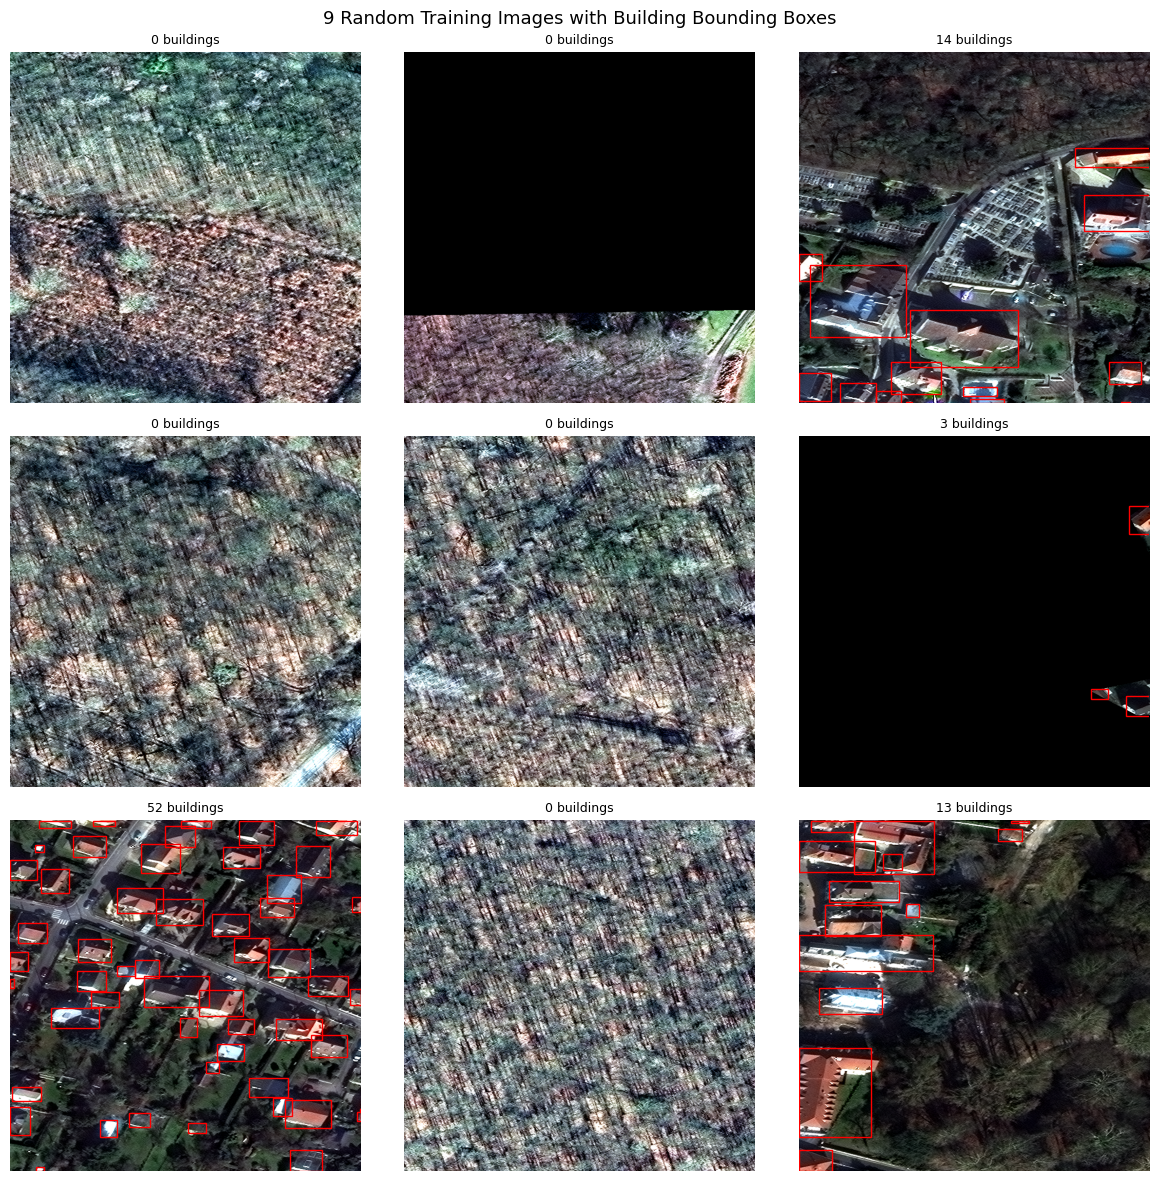

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random, os

train_imgs = glob.glob('data/train/images/*.png')
sample = random.sample(train_imgs, 9)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, img_path in zip(axes.flatten(), sample):
    img = Image.open(img_path)
    w, h = img.size
    ax.imshow(img)

    label_path = img_path.replace('/images/', '/labels/').replace('.png', '.txt')
    num_buildings = 0
    if os.path.exists(label_path):
        with open(label_path) as f:
            lines = [l.strip() for l in f if l.strip()]
        num_buildings = len(lines)
        for line in lines:
            _, xc, yc, bw, bh = map(float, line.split())
            x = (xc - bw/2) * w
            y = (yc - bh/2) * h
            rect = patches.Rectangle((x, y), bw*w, bh*h,
                                      linewidth=1, edgecolor='red', facecolor='none')
            ax.add_patch(rect)

    ax.set_title(f'{num_buildings} buildings', fontsize=9)
    ax.axis('off')

plt.suptitle('9 Random Training Images with Building Bounding Boxes', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
import numpy as np

label_files = glob.glob('data/train/labels/*.txt')
building_counts = []

for lf in label_files:
    with open(lf) as f:
        lines = [l.strip() for l in f if l.strip()]
    building_counts.append(len(lines))

print(f"Total training images:        {len(building_counts)}")
print(f"Average buildings per image:  {np.mean(building_counts):.2f}")
print(f"Max buildings in one image:   {max(building_counts)}")
print(f"Min buildings in one image:   {min(building_counts)}")
print(f"Images with 0 buildings:      {building_counts.count(0)}")

Total training images:        918
Average buildings per image:  14.25
Max buildings in one image:   82
Min buildings in one image:   0
Images with 0 buildings:      411


## Step 2.3 — EDA Observations

**Average number of buildings per image:**
14.25 buildings per image on average, though this varies widely —
from 0 buildings (411 empty images) up to 82 buildings in a single image.

**Do images look consistent in size and quality?**
Yes, all images are the same resolution (uniform satellite tile crops).
Quality is generally consistent, though some images appear darker or
have slight color variation due to atmospheric and lighting conditions.

**What challenges do you think the model might face?**
- Dense clusters of buildings with overlapping or touching rooftops
- Small building footprints that are hard to detect at this resolution
- 411 out of 918 training images have zero buildings (high background ratio),
  which may bias the model toward predicting fewer detections
- Shadows cast by tall buildings can obscure roof edges
- Varying roof colors and materials make it harder to generalize

In [10]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
    data='dataset.yaml',
    epochs=30,
    imgsz=640,
    batch=16,
    name='building_detector',
    project='runs/detect',
    patience=10,
    device=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.65 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False

In [11]:
import pandas as pd

csv_path = '/content/runs/detect/runs/detect/building_detector/results.csv'
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

last = df.iloc[-1]
print(f"Final Epoch:    {len(df)}")
print(f"Train box_loss: {last['train/box_loss']:.4f}")
print(f"Val box_loss:   {last['val/box_loss']:.4f}")
print(f"mAP@50:         {last['metrics/mAP50(B)']:.4f}")

Final Epoch:    30
Train box_loss: 1.2187
Val box_loss:   1.3193
mAP@50:         0.8052


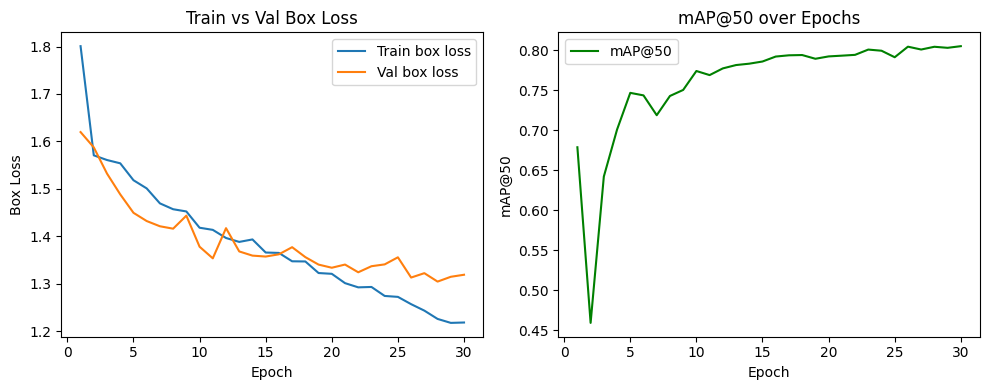

In [13]:
import matplotlib.pyplot as plt

epochs = df.index + 1

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, df['train/box_loss'], label='Train box loss')
plt.plot(epochs, df['val/box_loss'],   label='Val box loss')
plt.xlabel('Epoch')
plt.ylabel('Box Loss')
plt.title('Train vs Val Box Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, df['metrics/mAP50(B)'], label='mAP@50', color='green')
plt.xlabel('Epoch')
plt.ylabel('mAP@50')
plt.title('mAP@50 over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

## Step 4.3 — Training Curve Observations

**Did val loss follow train loss?**
Yes, the validation loss consistently followed the training loss downward
across all 30 epochs, indicating healthy learning without overfitting.

**Did the model plateau or keep improving?**
The model showed steady improvement in mAP@50 from 0.679 at epoch 1 to 0.805
by epoch 26, then plateaued slightly in the final epochs (0.801–0.805),
suggesting the model largely converged within the 30 epoch budget.

In [14]:
from ultralytics import YOLO

model = YOLO('/content/runs/detect/runs/detect/building_detector/weights/best.pt')

metrics = model.val(
    data='dataset.yaml',
    split='val',
)

p     = metrics.box.mp
r     = metrics.box.mr
map50 = metrics.box.map50
f1    = 2 * p * r / (p + r)

print(f"mAP@50:    {map50:.4f}")
print(f"Precision: {p:.4f}")
print(f"Recall:    {r:.4f}")
print(f"F1 Score:  {f1:.4f}")

Ultralytics 8.4.65 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4454.4±851.3 MB/s, size: 920.5 KB)
val: Scanning /content/data/val/labels.cache... 115 images, 54 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 115/115 37.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.0it/s 7.7s
                   all        115       1734      0.813      0.737      0.802      0.493
Speed: 9.5ms preprocess, 11.2ms inference, 0.0ms loss, 6.3ms postprocess per image
Results saved to /content/runs/detect/val
mAP@50:    0.8022
Precision: 0.8126
Recall:    0.7370
F1 Score:  0.7730


## Step 5 — Evaluation Results

| Metric     | Your Value | What it means in plain English |
|------------|------------|-------------------------------|
| mAP@50     | 0.8022     | Model detects buildings correctly 80.2% of the time at IoU=0.5 |
| Precision  | 0.8126     | Of all predicted boxes, 81.3% were actual buildings |
| Recall     | 0.7370     | Of all real buildings, the model found 73.7% of them |
| F1 Score   | 0.7730     | Balanced score between precision and recall |

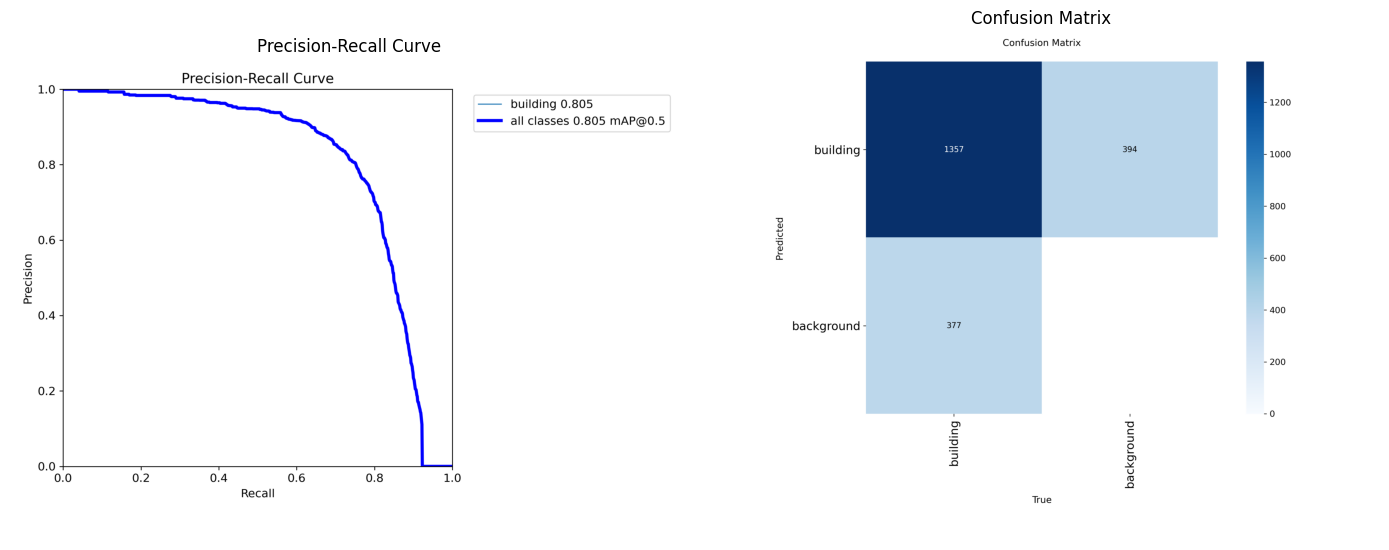

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

runs_dir = '/content/runs/detect/runs/detect/building_detector'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(Image.open(f'{runs_dir}/BoxPR_curve.png'))
axes[0].set_title('Precision-Recall Curve')
axes[0].axis('off')

axes[1].imshow(Image.open(f'{runs_dir}/confusion_matrix.png'))
axes[1].set_title('Confusion Matrix')
axes[1].axis('off')

plt.tight_layout()
plt.show()

AOI_3_Paris_img463.png: true=10, pred=7
AOI_3_Paris_img122.png: true=43, pred=42
AOI_3_Paris_img1059.png: true=38, pred=35
AOI_3_Paris_img636.png: true=54, pred=50
AOI_3_Paris_img1480.png: true=0, pred=0
AOI_3_Paris_img1429.png: true=0, pred=0
AOI_3_Paris_img1400.png: true=69, pred=71
AOI_3_Paris_img1252.png: true=0, pred=0
AOI_3_Paris_img1199.png: true=0, pred=0
AOI_3_Paris_img545.png: true=26, pred=24

Mean Absolute Error (count): 1.50


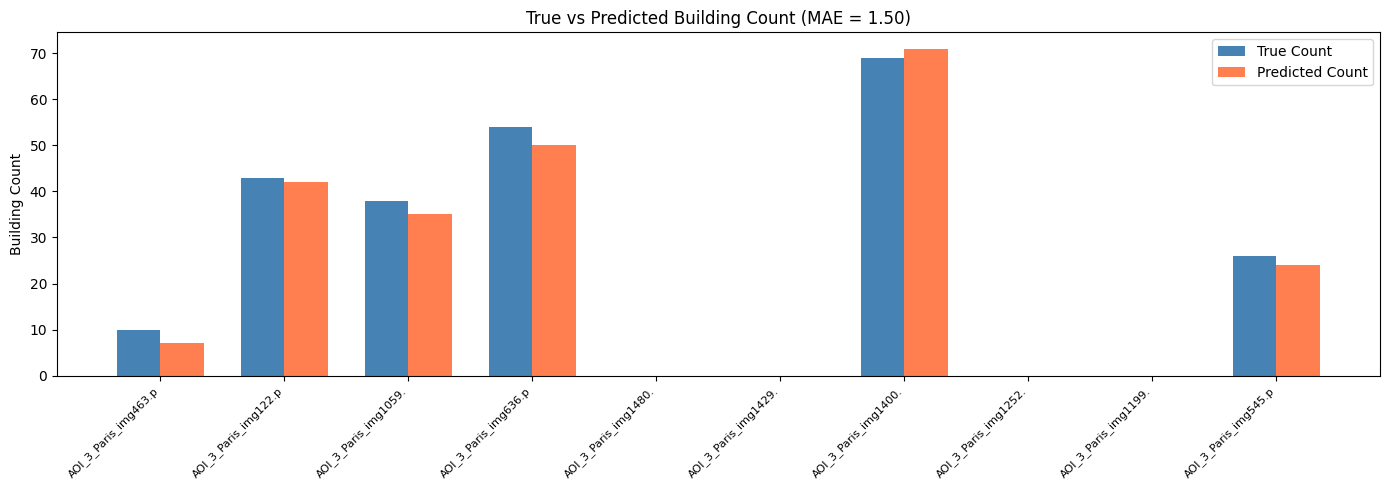

In [16]:
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os, glob, random, time

model = YOLO('/content/runs/detect/runs/detect/building_detector/weights/best.pt')

def detect_buildings(image_path, conf=0.25):
    results = model(image_path, conf=conf, verbose=False)
    boxes = results[0].boxes
    count = len(boxes)
    confidences = boxes.conf.cpu().numpy() if count > 0 else []
    return count, confidences, results[0]

# Sample 10 val images
val_imgs = sorted(glob.glob('data/val/images/*.png'))
random.seed(42)
sample_imgs = random.sample(val_imgs, 10)

true_counts, pred_counts, img_names = [], [], []

for img_path in sample_imgs:
    fname = os.path.basename(img_path)
    label_path = img_path.replace('/images/', '/labels/').replace('.png', '.txt')

    if os.path.exists(label_path):
        with open(label_path) as f:
            lines = [l.strip() for l in f if l.strip()]
        true_count = len(lines)
    else:
        true_count = 0

    pred_count, _, _ = detect_buildings(img_path)
    true_counts.append(true_count)
    pred_counts.append(pred_count)
    img_names.append(fname[:20])
    print(f"{fname}: true={true_count}, pred={pred_count}")

mae = np.mean(np.abs(np.array(true_counts) - np.array(pred_counts)))
print(f"\nMean Absolute Error (count): {mae:.2f}")

x = np.arange(len(img_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, true_counts, width, label='True Count',      color='steelblue')
ax.bar(x + width/2, pred_counts, width, label='Predicted Count', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(img_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Building Count')
ax.set_title(f'True vs Predicted Building Count (MAE = {mae:.2f})')
ax.legend()
plt.tight_layout()
plt.show()

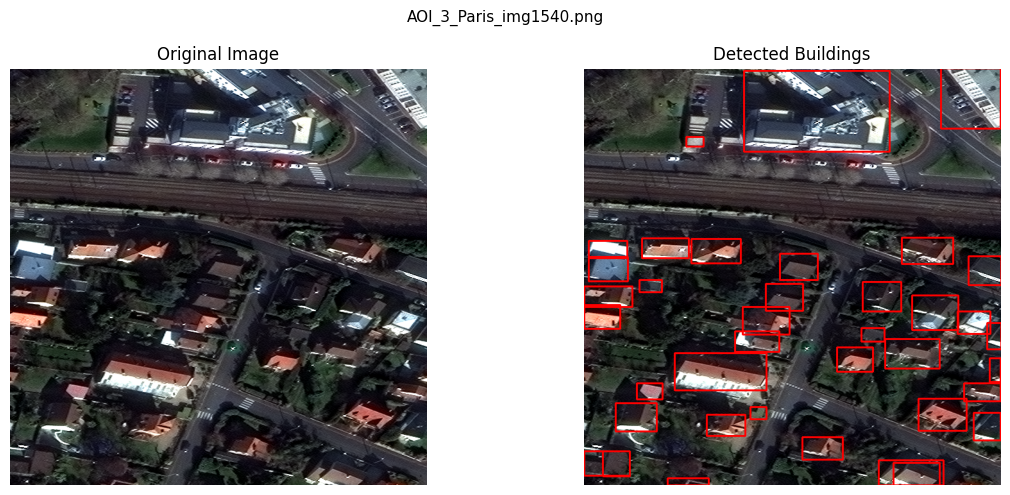

Image: AOI_3_Paris_img1540.png
Buildings detected: 38
Avg confidence: 0.63
Processing time: 49.1 ms
----------------------------------------


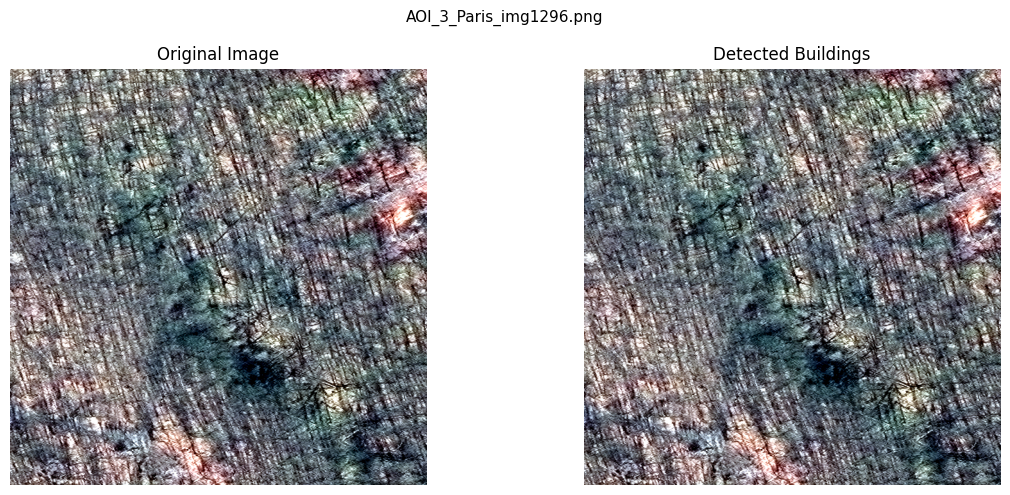

Image: AOI_3_Paris_img1296.png
Buildings detected: 0
Avg confidence: 0.00
Processing time: 59.3 ms
----------------------------------------


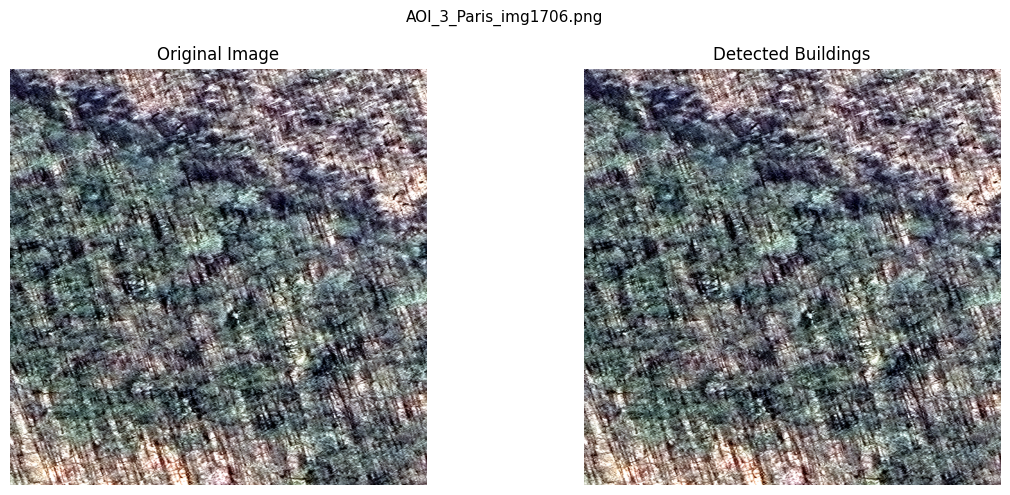

Image: AOI_3_Paris_img1706.png
Buildings detected: 0
Avg confidence: 0.00
Processing time: 54.8 ms
----------------------------------------


In [18]:
import cv2

def full_pipeline(image_path, conf=0.25):
    start = time.time()

    orig = Image.open(image_path).convert('RGB')
    orig_arr = np.array(orig)

    results = model(image_path, conf=conf, verbose=False)
    boxes = results[0].boxes
    count = len(boxes)
    confidences = boxes.conf.cpu().numpy() if count > 0 else np.array([])
    avg_conf = float(np.mean(confidences)) if count > 0 else 0.0

    elapsed = (time.time() - start) * 1000

    ann_arr = orig_arr.copy()
    if count > 0:
        for box in boxes.xyxy.cpu().numpy():
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(ann_arr, (x1, y1), (x2, y2), (255, 0, 0), 2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(orig_arr)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(ann_arr)
    axes[1].set_title('Detected Buildings')
    axes[1].axis('off')

    plt.suptitle(os.path.basename(image_path), fontsize=11)
    plt.tight_layout()
    plt.show()

    print(f"Image: {os.path.basename(image_path)}")
    print(f"Buildings detected: {count}")
    print(f"Avg confidence: {avg_conf:.2f}")
    print(f"Processing time: {elapsed:.1f} ms")
    print("-" * 40)

# Test on 3 val images
random.seed(7)
three_imgs = random.sample(val_imgs, 3)

for img_path in three_imgs:
    full_pipeline(img_path)